# ST-GCN Study

Systematic comparison of ST-GCN (Spatial-Temporal Graph Convolutional Network) configurations
for per-rep push-up form classification.

**Key advantage over R3D:** ST-GCN operates on skeleton keypoints (joint coordinates),
not raw pixels. This makes it invariant to appearance, background, lighting, and camera angle.

**Study design:**
1. **Experiment A**: Baseline ST-GCN (medium, 2-channel xy)
2. **Experiment B**: Input channels comparison (2-channel xy vs 3-channel xy+confidence)
3. **Experiment C**: Model capacity (small vs medium vs large)
4. **Experiment D**: Temporal sampling (16 vs 32 vs 64 frames)
5. **Experiment E**: Hyperparameter tuning (LR + batch size)
6. **Overfitting analysis** + final comparison

All experiments use 5-fold stratified CV split by video to prevent data leakage.

## Setup + Data Loading

In [1]:
import logging
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from model import PushUpSTGCN, CONFIGS
from datasets import PushUpRepSkeletonDataset
from training import run_rep_kfold_cv
from data_loader import load_annotations, extract_keypoints, attach_keypoints

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

# ============================================================
# CONFIGURATION — Vast.ai paths
# ============================================================
ANNOTATIONS   = Path("annotations_template.xlsx")
VIDEO_DIR     = Path("videos")
KEYPOINT_DIR  = Path("keypoints")
OUTPUT_DIR    = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# CV settings
RANDOM_STATE = 42
N_SPLITS     = 5

# Device
if torch.cuda.is_available():
    DEVICE = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"Device: {DEVICE}")
print(f"Video dir: {VIDEO_DIR}")
print(f"Annotations: {ANNOTATIONS}")

Device: cuda
Video dir: videos
Annotations: annotations_template.xlsx


In [2]:
# Load annotations and attach keypoints
rep_segments = load_annotations(ANNOTATIONS, VIDEO_DIR)

n_good = sum(1 for r in rep_segments if r["label"] == 0)
n_bad  = sum(1 for r in rep_segments if r["label"] == 1)
unique_videos = set(r["video_id"] for r in rep_segments)

print(f"Total reps: {len(rep_segments)} (good={n_good}, bad={n_bad})")
print(f"Unique videos: {len(unique_videos)}")
print(f"Mean reps/video: {len(rep_segments)/max(len(unique_videos),1):.1f}")

if rep_segments:
    rep_lengths = [r["end_frame"] - r["start_frame"] for r in rep_segments]
    print(f"Rep length (frames): min={min(rep_lengths)}, max={max(rep_lengths)}, "
          f"median={np.median(rep_lengths):.0f}")

INFO: Loaded 357 reps from annotations_template.xlsx (skipped 6)


Total reps: 357 (good=165, bad=192)
Unique videos: 238
Mean reps/video: 1.5
Rep length (frames): min=11, max=396, median=63


In [3]:
# Extract keypoints (skips already-extracted videos)
extract_keypoints(rep_segments, KEYPOINT_DIR)

# Attach keypoints to rep dicts
attach_keypoints(rep_segments, KEYPOINT_DIR)

# Verify
has_kps = sum(1 for r in rep_segments if "keypoints" in r)
print(f"Reps with keypoints: {has_kps}/{len(rep_segments)}")

# Filter to only reps with keypoints
reps_with_kps = [r for r in rep_segments if "keypoints" in r]
print(f"Using {len(reps_with_kps)} reps for experiments")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


INFO: Keypoints already exist: 1.npy
INFO: Keypoints already exist: 10.npy
INFO: Keypoints already exist: 11.npy
INFO: Keypoints already exist: 12.npy
INFO: Keypoints already exist: 13.npy
INFO: Keypoints already exist: 14.npy
INFO: Keypoints already exist: 15.npy
INFO: Keypoints already exist: 16.npy
INFO: Keypoints already exist: 17.npy
INFO: Keypoints already exist: 18.npy
INFO: Keypoints already exist: 19.npy
INFO: Keypoints already exist: 2.npy
INFO: Keypoints already exist: 20.npy
INFO: Keypoints already exist: 20260227_084626000_iOS.npy
INFO: Keypoints already exist: 20260227_084636000_iOS.npy
INFO: Keypoints already exist: 20260227_084906000_iOS.npy
INFO: Keypoints already exist: 20260227_084918000_iOS.npy
INFO: Keypoints already exist: 20260227_084926000_iOS.npy
INFO: Keypoints already exist: 20260227_085026000_iOS.npy
INFO: Keypoints already exist: 20260227_090017000_iOS.npy
INFO: Keypoints already exist: 20260227_090022000_iOS.npy
INFO: Keypoints already exist: 20260227_0900

Reps with keypoints: 357/357
Using 357 reps for experiments


---
## Experiment A: Baseline ST-GCN

Medium architecture (3 blocks: 64-64-128), 2-channel input (x,y), 32 frames per rep.
This is the default configuration.

In [4]:
# Baseline: medium, 2-channel, 32 frames
BASELINE_N_FRAMES = 32
BASELINE_IN_CH = 2
BASELINE_CHANNELS = CONFIGS["medium"]  # [64, 64, 128]

def make_baseline_model():
    return PushUpSTGCN(in_channels=BASELINE_IN_CH, channels=BASELINE_CHANNELS)

def make_baseline_dataset(reps):
    return PushUpRepSkeletonDataset(reps, n_frames=BASELINE_N_FRAMES,
                                    in_channels=BASELINE_IN_CH, augment=False)

def make_baseline_dataset_aug(reps):
    return PushUpRepSkeletonDataset(reps, n_frames=BASELINE_N_FRAMES,
                                    in_channels=BASELINE_IN_CH, augment=True)

m = make_baseline_model()
print(f"Experiment A: Baseline ST-GCN")
print(f"  Architecture: {BASELINE_CHANNELS}")
print(f"  Input: {BASELINE_IN_CH} channels, {BASELINE_N_FRAMES} frames")
print(f"  Trainable params: {m.trainable_param_count():,}")

t0 = time.time()
results_A = run_rep_kfold_cv(
    model_factory=make_baseline_model,
    dataset_factory=make_baseline_dataset,
    rep_segments=reps_with_kps,
    n_splits=N_SPLITS,
    n_epochs=50,
    batch_size=16,
    lr=1e-3,
    patience=15,
    device_str=DEVICE,
    random_state=RANDOM_STATE,
    train_dataset_factory=make_baseline_dataset_aug,
)
time_A = time.time() - t0

accs_A = [f["val_accuracy"] for f in results_A["fold_results"]]
print(f"\nExperiment A results:")
print(f"  Per-fold: {[f'{a:.1%}' for a in accs_A]}")
print(f"  Mean: {np.mean(accs_A):.1%} +/- {np.std(accs_A):.1%}")
print(f"  Time: {time_A:.0f}s")

INFO: Fold 0: train=288 reps (190 vids), val=69 reps (48 vids)


Experiment A: Baseline ST-GCN
  Architecture: [64, 64, 128]
  Input: 2 channels, 32 frames
  Trainable params: 244,290
  Fold 0 | Epoch 01/50 | train_loss=0.7213 | val_loss=0.6833 | val_acc=50.7% *
  Fold 0 | Epoch 02/50 | train_loss=0.6696 | val_loss=0.6824 | val_acc=66.7% *
  Fold 0 | Epoch 03/50 | train_loss=0.6609 | val_loss=0.7362 | val_acc=59.4%
  Fold 0 | Epoch 04/50 | train_loss=0.6400 | val_loss=0.7552 | val_acc=56.5%
  Fold 0 | Epoch 05/50 | train_loss=0.6450 | val_loss=0.9858 | val_acc=59.4%
  Fold 0 | Epoch 06/50 | train_loss=0.6357 | val_loss=0.7140 | val_acc=60.9%
  Fold 0 | Epoch 07/50 | train_loss=0.6549 | val_loss=0.9308 | val_acc=52.2%
  Fold 0 | Epoch 08/50 | train_loss=0.6316 | val_loss=0.9522 | val_acc=55.1%
  Fold 0 | Epoch 09/50 | train_loss=0.6237 | val_loss=0.8258 | val_acc=56.5%
  Fold 0 | Epoch 10/50 | train_loss=0.6002 | val_loss=0.7722 | val_acc=58.0%
  Fold 0 | Epoch 11/50 | train_loss=0.6629 | val_loss=0.8613 | val_acc=58.0%
  Fold 0 | Epoch 12/50 | train

INFO: Fold 0: early stopping at epoch 16 (best_acc=0.6667)
INFO: Fold 0: val_accuracy=0.6667
INFO: Fold 1: train=287 reps (190 vids), val=70 reps (48 vids)


  Fold 0 | Epoch 17/50 | train_loss=0.5827 | val_loss=1.0180 | val_acc=55.1%
  Fold 1 | Epoch 01/50 | train_loss=0.7052 | val_loss=0.6284 | val_acc=51.4% *
  Fold 1 | Epoch 02/50 | train_loss=0.6679 | val_loss=0.6006 | val_acc=70.0% *
  Fold 1 | Epoch 03/50 | train_loss=0.6886 | val_loss=0.6059 | val_acc=61.4%
  Fold 1 | Epoch 04/50 | train_loss=0.6749 | val_loss=0.6405 | val_acc=61.4%
  Fold 1 | Epoch 05/50 | train_loss=0.6503 | val_loss=0.6441 | val_acc=62.9%
  Fold 1 | Epoch 06/50 | train_loss=0.6344 | val_loss=0.6172 | val_acc=61.4%
  Fold 1 | Epoch 07/50 | train_loss=0.6420 | val_loss=0.6332 | val_acc=64.3%
  Fold 1 | Epoch 08/50 | train_loss=0.6273 | val_loss=0.5954 | val_acc=58.6%
  Fold 1 | Epoch 09/50 | train_loss=0.5973 | val_loss=0.6930 | val_acc=54.3%
  Fold 1 | Epoch 10/50 | train_loss=0.6561 | val_loss=0.9725 | val_acc=55.7%
  Fold 1 | Epoch 11/50 | train_loss=0.6260 | val_loss=0.6280 | val_acc=57.1%
  Fold 1 | Epoch 12/50 | train_loss=0.6374 | val_loss=0.6185 | val_acc=5

INFO: Fold 1: early stopping at epoch 16 (best_acc=0.7000)
INFO: Fold 1: val_accuracy=0.7000
INFO: Fold 2: train=289 reps (190 vids), val=68 reps (48 vids)


...

  Fold 2 | Epoch 50/50 | train_loss=0.3406 | val_loss=0.5046 | val_acc=83.8%
  Fold 3 | Epoch 01/50 | train_loss=0.7784 | val_loss=0.7163 | val_acc=44.0% *
  Fold 3 | Epoch 02/50 | train_loss=0.6652 | val_loss=0.7059 | val_acc=56.0% *
  Fold 3 | Epoch 03/50 | train_loss=0.6855 | val_loss=0.6358 | val_acc=61.3% *
  Fold 3 | Epoch 04/50 | train_loss=0.6630 | val_loss=0.6822 | val_acc=64.0% *
  Fold 3 | Epoch 05/50 | train_loss=0.6441 | val_loss=0.6789 | val_acc=56.0%
  Fold 3 | Epoch 06/50 | train_loss=0.6635 | val_loss=0.6786 | val_acc=60.0%
  Fold 3 | Epoch 07/50 | train_loss=0.6449 | val_loss=0.6482 | val_acc=62.7%
  Fold 3 | Epoch 08/50 | train_loss=0.6479 | val_loss=0.6336 | val_acc=64.0%
  Fold 3 | Epoch 09/50 | train_loss=0.6363 | val_loss=0.6453 | val_acc=62.7%
  Fold 3 | Epoch 10/50 | train_loss=0.6173 | val_loss=0.6184 | val_acc=65.3% *
  Fold 3 | Epoch 11/50 | train_loss=0.6248 | val_loss=0.6373 | val_acc=64.0%
  Fold 3 | Epoch 12/50 | train_loss=0.6109 | val_loss=0.6416 | val

INFO: Fold 3: early stopping at epoch 37 (best_acc=0.7733)
INFO: Fold 3: val_accuracy=0.7733
INFO: Fold 4: train=282 reps (191 vids), val=75 reps (47 vids)


  Fold 3 | Epoch 38/50 | train_loss=0.4364 | val_loss=0.6111 | val_acc=68.0%
  Fold 4 | Epoch 01/50 | train_loss=0.6971 | val_loss=0.8144 | val_acc=48.0% *
  Fold 4 | Epoch 02/50 | train_loss=0.6587 | val_loss=0.8352 | val_acc=49.3% *
  Fold 4 | Epoch 03/50 | train_loss=0.6732 | val_loss=0.9917 | val_acc=54.7% *
  Fold 4 | Epoch 04/50 | train_loss=0.6398 | val_loss=0.7347 | val_acc=58.7% *
  Fold 4 | Epoch 05/50 | train_loss=0.6319 | val_loss=0.7681 | val_acc=56.0%
  Fold 4 | Epoch 06/50 | train_loss=0.6420 | val_loss=0.7528 | val_acc=60.0% *
  Fold 4 | Epoch 07/50 | train_loss=0.6121 | val_loss=0.6862 | val_acc=53.3%
  Fold 4 | Epoch 08/50 | train_loss=0.6110 | val_loss=0.7100 | val_acc=54.7%
  Fold 4 | Epoch 09/50 | train_loss=0.5932 | val_loss=0.6678 | val_acc=60.0%
  Fold 4 | Epoch 10/50 | train_loss=0.6056 | val_loss=0.9556 | val_acc=52.0%
  Fold 4 | Epoch 11/50 | train_loss=0.6298 | val_loss=0.6607 | val_acc=58.7%
  Fold 4 | Epoch 12/50 | train_loss=0.6014 | val_loss=0.6677 | val

INFO: Fold 4: val_accuracy=0.8533


  Fold 4 | Epoch 50/50 | train_loss=0.2992 | val_loss=0.5332 | val_acc=82.7%

Experiment A results:
  Per-fold: ['66.7%', '70.0%', '83.8%', '77.3%', '85.3%']
  Mean: 76.6% +/- 7.4%
  Time: 71s


---
## Experiment B: Input Channels (2 vs 3)

Compare 2-channel (x, y) vs 3-channel (x, y, confidence) input.
The confidence channel tells the model how reliable each keypoint is.

In [5]:
# 3-channel: x, y, confidence
def make_3ch_model():
    return PushUpSTGCN(in_channels=3, channels=BASELINE_CHANNELS)

def make_3ch_dataset(reps):
    return PushUpRepSkeletonDataset(reps, n_frames=BASELINE_N_FRAMES,
                                    in_channels=3, augment=False)

def make_3ch_dataset_aug(reps):
    return PushUpRepSkeletonDataset(reps, n_frames=BASELINE_N_FRAMES,
                                    in_channels=3, augment=True)

print(f"Experiment B: 3-channel input (x, y, confidence)")
print(f"  Trainable params: {make_3ch_model().trainable_param_count():,}")

t0 = time.time()
results_B = run_rep_kfold_cv(
    model_factory=make_3ch_model,
    dataset_factory=make_3ch_dataset,
    rep_segments=reps_with_kps,
    n_splits=N_SPLITS,
    n_epochs=50,
    batch_size=16,
    lr=1e-3,
    patience=15,
    device_str=DEVICE,
    random_state=RANDOM_STATE,
    train_dataset_factory=make_3ch_dataset_aug,
)
time_B = time.time() - t0

accs_B = [f["val_accuracy"] for f in results_B["fold_results"]]
print(f"\nExperiment B results:")
print(f"  Per-fold: {[f'{a:.1%}' for a in accs_B]}")
print(f"  Mean: {np.mean(accs_B):.1%} +/- {np.std(accs_B):.1%}")
print(f"  Time: {time_B:.0f}s")

INFO: Fold 0: train=288 reps (190 vids), val=69 reps (48 vids)


Experiment B: 3-channel input (x, y, confidence)
  Trainable params: 244,418
  Fold 0 | Epoch 01/50 | train_loss=0.7393 | val_loss=0.7373 | val_acc=53.6% *
  Fold 0 | Epoch 02/50 | train_loss=0.6731 | val_loss=0.8059 | val_acc=55.1% *
  Fold 0 | Epoch 03/50 | train_loss=0.6734 | val_loss=0.6740 | val_acc=63.8% *
  Fold 0 | Epoch 04/50 | train_loss=0.6567 | val_loss=0.7544 | val_acc=53.6%
  Fold 0 | Epoch 05/50 | train_loss=0.6485 | val_loss=0.7424 | val_acc=62.3%
  Fold 0 | Epoch 06/50 | train_loss=0.6358 | val_loss=0.8675 | val_acc=52.2%
  Fold 0 | Epoch 07/50 | train_loss=0.6220 | val_loss=0.9217 | val_acc=56.5%
  Fold 0 | Epoch 08/50 | train_loss=0.6378 | val_loss=0.8471 | val_acc=53.6%
  Fold 0 | Epoch 09/50 | train_loss=0.6231 | val_loss=0.9973 | val_acc=56.5%
  Fold 0 | Epoch 10/50 | train_loss=0.6025 | val_loss=0.8860 | val_acc=58.0%
  Fold 0 | Epoch 11/50 | train_loss=0.5817 | val_loss=0.8170 | val_acc=66.7% *
  Fold 0 | Epoch 12/50 | train_loss=0.5814 | val_loss=0.8955 | val_a

INFO: Fold 0: val_accuracy=0.7681
INFO: Fold 1: train=287 reps (190 vids), val=70 reps (48 vids)


  Fold 0 | Epoch 50/50 | train_loss=0.3631 | val_loss=0.8606 | val_acc=65.2%
  Fold 1 | Epoch 01/50 | train_loss=0.6887 | val_loss=0.8154 | val_acc=48.6% *
  Fold 1 | Epoch 02/50 | train_loss=0.7243 | val_loss=0.6188 | val_acc=58.6% *
  Fold 1 | Epoch 03/50 | train_loss=0.6620 | val_loss=0.6347 | val_acc=54.3%
  Fold 1 | Epoch 04/50 | train_loss=0.6699 | val_loss=0.6481 | val_acc=55.7%
  Fold 1 | Epoch 05/50 | train_loss=0.6595 | val_loss=0.6094 | val_acc=64.3% *
  Fold 1 | Epoch 06/50 | train_loss=0.6251 | val_loss=0.6762 | val_acc=54.3%
  Fold 1 | Epoch 07/50 | train_loss=0.6285 | val_loss=0.6375 | val_acc=52.9%
  Fold 1 | Epoch 08/50 | train_loss=0.6083 | val_loss=0.6119 | val_acc=60.0%
  Fold 1 | Epoch 09/50 | train_loss=0.6128 | val_loss=0.6365 | val_acc=54.3%
  Fold 1 | Epoch 10/50 | train_loss=0.5944 | val_loss=0.6211 | val_acc=61.4%
  Fold 1 | Epoch 11/50 | train_loss=0.5924 | val_loss=0.7537 | val_acc=58.6%
  Fold 1 | Epoch 12/50 | train_loss=0.5735 | val_loss=0.6865 | val_acc

INFO: Fold 1: val_accuracy=0.7714
INFO: Fold 2: train=289 reps (190 vids), val=68 reps (48 vids)


...

  Fold 2 | Epoch 44/50 | train_loss=0.3666 | val_loss=0.7116 | val_acc=70.6%
  Fold 3 | Epoch 01/50 | train_loss=0.7003 | val_loss=0.7035 | val_acc=46.7% *
  Fold 3 | Epoch 02/50 | train_loss=0.6903 | val_loss=0.5960 | val_acc=65.3% *
  Fold 3 | Epoch 03/50 | train_loss=0.6614 | val_loss=0.6146 | val_acc=72.0% *
  Fold 3 | Epoch 04/50 | train_loss=0.6439 | val_loss=0.5831 | val_acc=69.3%
  Fold 3 | Epoch 05/50 | train_loss=0.6872 | val_loss=0.6327 | val_acc=58.7%
  Fold 3 | Epoch 06/50 | train_loss=0.6570 | val_loss=0.6584 | val_acc=62.7%
  Fold 3 | Epoch 07/50 | train_loss=0.6415 | val_loss=0.6006 | val_acc=72.0%
  Fold 3 | Epoch 08/50 | train_loss=0.6131 | val_loss=0.7101 | val_acc=62.7%
  Fold 3 | Epoch 09/50 | train_loss=0.6270 | val_loss=0.7395 | val_acc=57.3%
  Fold 3 | Epoch 10/50 | train_loss=0.5917 | val_loss=0.5446 | val_acc=73.3% *
  Fold 3 | Epoch 11/50 | train_loss=0.6042 | val_loss=0.5788 | val_acc=72.0%
  Fold 3 | Epoch 12/50 | train_loss=0.5866 | val_loss=0.6400 | val_a

INFO: Fold 3: val_accuracy=0.9067
INFO: Fold 4: train=282 reps (191 vids), val=75 reps (47 vids)


  Fold 3 | Epoch 50/50 | train_loss=0.3166 | val_loss=0.6504 | val_acc=74.7%
  Fold 4 | Epoch 01/50 | train_loss=0.7308 | val_loss=0.7480 | val_acc=49.3% *
  Fold 4 | Epoch 02/50 | train_loss=0.6502 | val_loss=0.7777 | val_acc=44.0%
  Fold 4 | Epoch 03/50 | train_loss=0.6451 | val_loss=0.8169 | val_acc=60.0% *
  Fold 4 | Epoch 04/50 | train_loss=0.6570 | val_loss=0.7808 | val_acc=60.0%
  Fold 4 | Epoch 05/50 | train_loss=0.6323 | val_loss=0.7703 | val_acc=66.7% *
  Fold 4 | Epoch 06/50 | train_loss=0.6226 | val_loss=0.7116 | val_acc=69.3% *
  Fold 4 | Epoch 07/50 | train_loss=0.6327 | val_loss=0.7841 | val_acc=61.3%
  Fold 4 | Epoch 08/50 | train_loss=0.6186 | val_loss=0.7359 | val_acc=60.0%
  Fold 4 | Epoch 09/50 | train_loss=0.6236 | val_loss=0.7762 | val_acc=54.7%
  Fold 4 | Epoch 10/50 | train_loss=0.6070 | val_loss=0.7398 | val_acc=57.3%
  Fold 4 | Epoch 11/50 | train_loss=0.5930 | val_loss=0.7720 | val_acc=56.0%
  Fold 4 | Epoch 12/50 | train_loss=0.5844 | val_loss=0.7337 | val_a

INFO: Fold 4: val_accuracy=0.8800


  Fold 4 | Epoch 50/50 | train_loss=0.2604 | val_loss=0.5748 | val_acc=84.0%

Experiment B results:
  Per-fold: ['76.8%', '77.1%', '79.4%', '90.7%', '88.0%']
  Mean: 82.4% +/- 5.8%
  Time: 100s


             Experiment Mean Accuracy  Std Time (s)
     A: 2-channel (x,y)         76.6% 7.4%       71
B: 3-channel (x,y,conf)         82.4% 5.8%      100

Winner: B: 3-channel (82.4%)


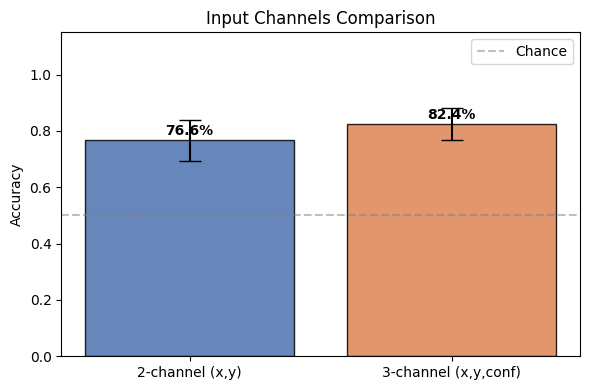

In [6]:
# Compare A vs B
mean_A = np.mean(accs_A)
mean_B = np.mean(accs_B)

comparison_ab = pd.DataFrame({
    "Experiment": ["A: 2-channel (x,y)", "B: 3-channel (x,y,conf)"],
    "Mean Accuracy": [f"{mean_A:.1%}", f"{mean_B:.1%}"],
    "Std": [f"{np.std(accs_A):.1%}", f"{np.std(accs_B):.1%}"],
    "Time (s)": [f"{time_A:.0f}", f"{time_B:.0f}"],
})
print(comparison_ab.to_string(index=False))

if mean_B > mean_A:
    WINNER_IN_CH = 3
    winner_ch_name = "B: 3-channel"
    winner_ch_accs = accs_B
    winner_ch_results = results_B
    winner_ch_time = time_B
else:
    WINNER_IN_CH = 2
    winner_ch_name = "A: 2-channel"
    winner_ch_accs = accs_A
    winner_ch_results = results_A
    winner_ch_time = time_A

print(f"\nWinner: {winner_ch_name} ({np.mean(winner_ch_accs):.1%})")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ["2-channel (x,y)", "3-channel (x,y,conf)"],
    [mean_A, mean_B],
    yerr=[np.std(accs_A), np.std(accs_B)],
    capsize=8, color=["#4C72B0", "#DD8452"], alpha=0.85, edgecolor="black",
)
for bar, m in zip(bars, [mean_A, mean_B]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{m:.1%}", ha="center", fontweight="bold")
ax.set_ylabel("Accuracy")
ax.set_title("Input Channels Comparison")
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Chance")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ab_channels.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Experiment C: Model Capacity

Compare three architectures using the winning input channel:
- **Small**: 2 blocks (32, 64)
- **Medium**: 3 blocks (64, 64, 128)
- **Large**: 4 blocks (64, 128, 128, 256)

In [7]:
capacity_results = {}

for config_name in ["small", "medium", "large"]:
    channels = CONFIGS[config_name]

    def make_model(ch=channels):
        return PushUpSTGCN(in_channels=WINNER_IN_CH, channels=ch)

    def make_dataset(reps, in_ch=WINNER_IN_CH):
        return PushUpRepSkeletonDataset(reps, n_frames=BASELINE_N_FRAMES,
                                        in_channels=in_ch, augment=False)

    def make_dataset_aug(reps, in_ch=WINNER_IN_CH):
        return PushUpRepSkeletonDataset(reps, n_frames=BASELINE_N_FRAMES,
                                        in_channels=in_ch, augment=True)

    n_params = make_model().trainable_param_count()
    print(f"\n{'='*60}")
    print(f"{config_name.upper()}: {channels} — {n_params:,} params")
    print(f"{'='*60}")

    t0 = time.time()
    res = run_rep_kfold_cv(
        model_factory=make_model,
        dataset_factory=make_dataset,
        rep_segments=reps_with_kps,
        n_splits=N_SPLITS,
        n_epochs=50,
        batch_size=16,
        lr=1e-3,
        patience=15,
        device_str=DEVICE,
        random_state=RANDOM_STATE,
        train_dataset_factory=make_dataset_aug,
    )
    elapsed = time.time() - t0

    accs = [f["val_accuracy"] for f in res["fold_results"]]
    print(f"  Per-fold: {[f'{a:.1%}' for a in accs]}")
    print(f"  Mean: {np.mean(accs):.1%} +/- {np.std(accs):.1%}")
    print(f"  Time: {elapsed:.0f}s")

    capacity_results[config_name] = {
        "accs": accs,
        "results": res,
        "time": elapsed,
        "params": n_params,
        "channels": channels,
    }

INFO: Fold 0: train=288 reps (190 vids), val=69 reps (48 vids)



SMALL: [32, 64] — 51,362 params
  Fold 0 | Epoch 01/50 | train_loss=0.6965 | val_loss=0.6950 | val_acc=55.1% *
  Fold 0 | Epoch 02/50 | train_loss=0.6625 | val_loss=0.7613 | val_acc=52.2%
  Fold 0 | Epoch 03/50 | train_loss=0.6523 | val_loss=0.7259 | val_acc=59.4% *
  Fold 0 | Epoch 04/50 | train_loss=0.6413 | val_loss=0.7592 | val_acc=53.6%
  Fold 0 | Epoch 05/50 | train_loss=0.6270 | val_loss=0.7617 | val_acc=56.5%
  Fold 0 | Epoch 06/50 | train_loss=0.6162 | val_loss=0.7975 | val_acc=47.8%
  Fold 0 | Epoch 07/50 | train_loss=0.6306 | val_loss=0.8341 | val_acc=53.6%
  Fold 0 | Epoch 08/50 | train_loss=0.6062 | val_loss=0.7611 | val_acc=59.4%
  Fold 0 | Epoch 09/50 | train_loss=0.6126 | val_loss=0.7510 | val_acc=59.4%
  Fold 0 | Epoch 10/50 | train_loss=0.5846 | val_loss=0.7380 | val_acc=56.5%
  Fold 0 | Epoch 11/50 | train_loss=0.5936 | val_loss=0.7763 | val_acc=53.6%
  Fold 0 | Epoch 12/50 | train_loss=0.5933 | val_loss=0.7447 | val_acc=56.5%
  Fold 0 | Epoch 13/50 | train_loss=0.5

INFO: Fold 0: early stopping at epoch 30 (best_acc=0.6232)
INFO: Fold 0: val_accuracy=0.6232
INFO: Fold 1: train=287 reps (190 vids), val=70 reps (48 vids)


  Fold 0 | Epoch 31/50 | train_loss=0.5225 | val_loss=0.8553 | val_acc=47.8%
  Fold 1 | Epoch 01/50 | train_loss=0.7313 | val_loss=0.7030 | val_acc=48.6% *
  Fold 1 | Epoch 02/50 | train_loss=0.6871 | val_loss=0.6113 | val_acc=57.1% *
  Fold 1 | Epoch 03/50 | train_loss=0.6725 | val_loss=0.6117 | val_acc=60.0% *
  Fold 1 | Epoch 04/50 | train_loss=0.6654 | val_loss=0.5833 | val_acc=61.4% *
  Fold 1 | Epoch 05/50 | train_loss=0.6738 | val_loss=0.6148 | val_acc=57.1%
  Fold 1 | Epoch 06/50 | train_loss=0.6513 | val_loss=0.6288 | val_acc=60.0%
  Fold 1 | Epoch 07/50 | train_loss=0.6436 | val_loss=0.6358 | val_acc=57.1%
  Fold 1 | Epoch 08/50 | train_loss=0.6207 | val_loss=0.6399 | val_acc=47.1%
  Fold 1 | Epoch 09/50 | train_loss=0.6259 | val_loss=0.5919 | val_acc=57.1%
  Fold 1 | Epoch 10/50 | train_loss=0.6219 | val_loss=0.5867 | val_acc=60.0%
  Fold 1 | Epoch 11/50 | train_loss=0.6256 | val_loss=0.6145 | val_acc=51.4%
  Fold 1 | Epoch 12/50 | train_loss=0.6092 | val_loss=0.6483 | val_a

INFO: Fold 1: early stopping at epoch 29 (best_acc=0.6429)
INFO: Fold 1: val_accuracy=0.6429
INFO: Fold 2: train=289 reps (190 vids), val=68 reps (48 vids)


...

  Fold 2 | Epoch 50/50 | train_loss=0.2961 | val_loss=0.5212 | val_acc=82.4% *
  Fold 3 | Epoch 01/50 | train_loss=0.8054 | val_loss=0.6885 | val_acc=54.7% *
  Fold 3 | Epoch 02/50 | train_loss=0.6946 | val_loss=0.6376 | val_acc=60.0% *
  Fold 3 | Epoch 03/50 | train_loss=0.6569 | val_loss=0.6678 | val_acc=60.0%
  Fold 3 | Epoch 04/50 | train_loss=0.6579 | val_loss=0.7012 | val_acc=53.3%
  Fold 3 | Epoch 05/50 | train_loss=0.6660 | val_loss=0.6218 | val_acc=70.7% *
  Fold 3 | Epoch 06/50 | train_loss=0.6396 | val_loss=0.8287 | val_acc=58.7%
  Fold 3 | Epoch 07/50 | train_loss=0.6308 | val_loss=0.6514 | val_acc=60.0%
  Fold 3 | Epoch 08/50 | train_loss=0.6220 | val_loss=0.6015 | val_acc=68.0%
  Fold 3 | Epoch 09/50 | train_loss=0.6179 | val_loss=0.6160 | val_acc=70.7%
  Fold 3 | Epoch 10/50 | train_loss=0.6248 | val_loss=0.7256 | val_acc=61.3%
  Fold 3 | Epoch 11/50 | train_loss=0.6064 | val_loss=0.6433 | val_acc=62.7%
  Fold 3 | Epoch 12/50 | train_loss=0.5575 | val_loss=0.7617 | val_a

INFO: Fold 3: early stopping at epoch 40 (best_acc=0.8133)
INFO: Fold 3: val_accuracy=0.8133
INFO: Fold 4: train=282 reps (191 vids), val=75 reps (47 vids)


  Fold 3 | Epoch 41/50 | train_loss=0.4131 | val_loss=0.6022 | val_acc=72.0%
  Fold 4 | Epoch 01/50 | train_loss=0.8086 | val_loss=0.8137 | val_acc=46.7% *
  Fold 4 | Epoch 02/50 | train_loss=0.6664 | val_loss=0.6810 | val_acc=49.3% *
  Fold 4 | Epoch 03/50 | train_loss=0.6673 | val_loss=0.7552 | val_acc=57.3% *
  Fold 4 | Epoch 04/50 | train_loss=0.6621 | val_loss=0.7172 | val_acc=60.0% *
  Fold 4 | Epoch 05/50 | train_loss=0.6457 | val_loss=0.7184 | val_acc=61.3% *
  Fold 4 | Epoch 06/50 | train_loss=0.6454 | val_loss=0.7019 | val_acc=60.0%
  Fold 4 | Epoch 07/50 | train_loss=0.6280 | val_loss=0.8825 | val_acc=56.0%
  Fold 4 | Epoch 08/50 | train_loss=0.6540 | val_loss=0.6724 | val_acc=64.0% *
  Fold 4 | Epoch 09/50 | train_loss=0.6271 | val_loss=0.7305 | val_acc=58.7%
  Fold 4 | Epoch 10/50 | train_loss=0.6024 | val_loss=0.6935 | val_acc=62.7%
  Fold 4 | Epoch 11/50 | train_loss=0.6168 | val_loss=0.8382 | val_acc=60.0%
  Fold 4 | Epoch 12/50 | train_loss=0.5940 | val_loss=0.7015 | v

INFO: Fold 4: val_accuracy=0.8267


  Fold 4 | Epoch 50/50 | train_loss=0.2935 | val_loss=0.6982 | val_acc=72.0%
  Per-fold: ['68.1%', '78.6%', '82.4%', '81.3%', '82.7%']
  Mean: 78.6% +/- 5.4%
  Time: 104s


                   Config    Params Mean Accuracy  Std Time (s)
           Small [32, 64]    51,362         69.9% 5.8%       60
     Medium [64, 64, 128]   244,418         78.3% 5.5%       80
Large [64, 128, 128, 256] 1,025,602         78.6% 5.4%      104


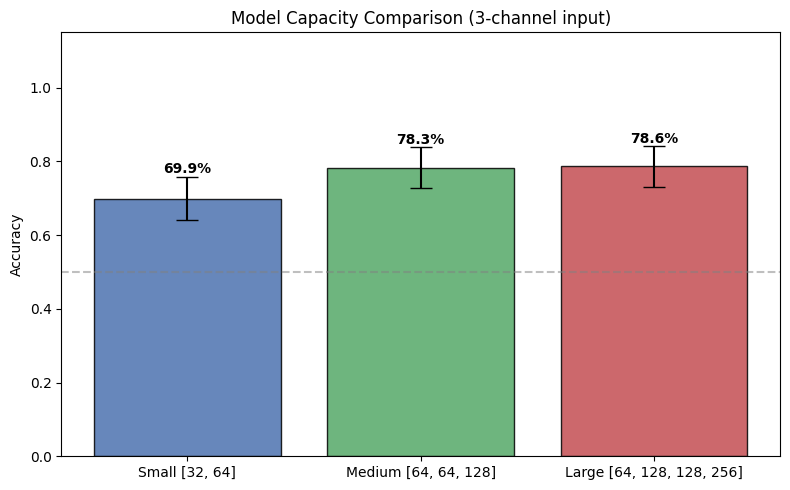


Best capacity: large (78.6%)


In [8]:
# Capacity comparison table and chart
cap_labels = ["small", "medium", "large"]
cap_display = [f"Small {CONFIGS['small']}", f"Medium {CONFIGS['medium']}",
               f"Large {CONFIGS['large']}"]

cap_df = pd.DataFrame({
    "Config": cap_display,
    "Params": [f"{capacity_results[k]['params']:,}" for k in cap_labels],
    "Mean Accuracy": [f"{np.mean(capacity_results[k]['accs']):.1%}" for k in cap_labels],
    "Std": [f"{np.std(capacity_results[k]['accs']):.1%}" for k in cap_labels],
    "Time (s)": [f"{capacity_results[k]['time']:.0f}" for k in cap_labels],
})
print(cap_df.to_string(index=False))

means_c = [np.mean(capacity_results[k]["accs"]) for k in cap_labels]
stds_c = [np.std(capacity_results[k]["accs"]) for k in cap_labels]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#4C72B0", "#55A868", "#C44E52"]
bars = ax.bar(cap_display, means_c, yerr=stds_c, capsize=8,
              color=colors, alpha=0.85, edgecolor="black")
for bar, m, s in zip(bars, means_c, stds_c):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.01,
            f"{m:.1%}", ha="center", fontweight="bold")
ax.set_ylabel("Accuracy")
ax.set_title(f"Model Capacity Comparison ({WINNER_IN_CH}-channel input)")
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "capacity_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

best_capacity = max(cap_labels, key=lambda k: np.mean(capacity_results[k]["accs"]))
WINNER_CHANNELS = CONFIGS[best_capacity]
print(f"\nBest capacity: {best_capacity} ({np.mean(capacity_results[best_capacity]['accs']):.1%})")

---
## Experiment D: Temporal Sampling

How many frames per rep? Compare 16, 32, and 64 frames
using the winning input channels and model capacity.

In [9]:
temporal_results = {}

for n_frames in [16, 32, 64]:
    def make_model(ch=WINNER_CHANNELS):
        return PushUpSTGCN(in_channels=WINNER_IN_CH, channels=ch)

    def make_dataset(reps, nf=n_frames):
        return PushUpRepSkeletonDataset(reps, n_frames=nf,
                                        in_channels=WINNER_IN_CH, augment=False)

    def make_dataset_aug(reps, nf=n_frames):
        return PushUpRepSkeletonDataset(reps, n_frames=nf,
                                        in_channels=WINNER_IN_CH, augment=True)

    print(f"\n--- n_frames={n_frames} ---")

    t0 = time.time()
    res = run_rep_kfold_cv(
        model_factory=make_model,
        dataset_factory=make_dataset,
        rep_segments=reps_with_kps,
        n_splits=N_SPLITS,
        n_epochs=50,
        batch_size=16,
        lr=1e-3,
        patience=15,
        device_str=DEVICE,
        random_state=RANDOM_STATE,
        train_dataset_factory=make_dataset_aug,
    )
    elapsed = time.time() - t0

    accs = [f["val_accuracy"] for f in res["fold_results"]]
    print(f"  Mean: {np.mean(accs):.1%} +/- {np.std(accs):.1%} ({elapsed:.0f}s)")

    temporal_results[n_frames] = {
        "accs": accs,
        "results": res,
        "time": elapsed,
    }

INFO: Fold 0: train=288 reps (190 vids), val=69 reps (48 vids)



--- n_frames=16 ---
  Fold 0 | Epoch 01/50 | train_loss=0.8255 | val_loss=0.6798 | val_acc=58.0% *
  Fold 0 | Epoch 02/50 | train_loss=0.6871 | val_loss=0.6508 | val_acc=62.3% *
  Fold 0 | Epoch 03/50 | train_loss=0.6408 | val_loss=0.6801 | val_acc=63.8% *
  Fold 0 | Epoch 04/50 | train_loss=0.6311 | val_loss=0.8333 | val_acc=53.6%
  Fold 0 | Epoch 05/50 | train_loss=0.6089 | val_loss=0.6378 | val_acc=73.9% *
  Fold 0 | Epoch 06/50 | train_loss=0.5626 | val_loss=0.8057 | val_acc=69.6%
  Fold 0 | Epoch 07/50 | train_loss=0.5498 | val_loss=1.1674 | val_acc=46.4%
  Fold 0 | Epoch 08/50 | train_loss=0.6181 | val_loss=0.7146 | val_acc=60.9%
  Fold 0 | Epoch 09/50 | train_loss=0.6238 | val_loss=0.8708 | val_acc=55.1%
  Fold 0 | Epoch 10/50 | train_loss=0.5819 | val_loss=0.6358 | val_acc=72.5%
  Fold 0 | Epoch 11/50 | train_loss=0.4728 | val_loss=0.6292 | val_acc=71.0%
  Fold 0 | Epoch 12/50 | train_loss=0.4543 | val_loss=0.7131 | val_acc=63.8%
  Fold 0 | Epoch 13/50 | train_loss=0.5652 | va

INFO: Fold 0: early stopping at epoch 39 (best_acc=0.8696)
INFO: Fold 0: val_accuracy=0.8696
INFO: Fold 1: train=287 reps (190 vids), val=70 reps (48 vids)


  Fold 0 | Epoch 40/50 | train_loss=0.2800 | val_loss=0.5236 | val_acc=75.4%
  Fold 1 | Epoch 01/50 | train_loss=0.7754 | val_loss=0.6391 | val_acc=52.9% *
  Fold 1 | Epoch 02/50 | train_loss=0.6556 | val_loss=0.6565 | val_acc=44.3%
  Fold 1 | Epoch 03/50 | train_loss=0.6126 | val_loss=0.6346 | val_acc=55.7% *
  Fold 1 | Epoch 04/50 | train_loss=0.6472 | val_loss=0.5907 | val_acc=57.1% *
  Fold 1 | Epoch 05/50 | train_loss=0.5973 | val_loss=0.7102 | val_acc=62.9% *
  Fold 1 | Epoch 06/50 | train_loss=0.5689 | val_loss=0.7948 | val_acc=52.9%
  Fold 1 | Epoch 07/50 | train_loss=0.5555 | val_loss=0.8796 | val_acc=60.0%
  Fold 1 | Epoch 08/50 | train_loss=0.5541 | val_loss=0.7554 | val_acc=60.0%
  Fold 1 | Epoch 09/50 | train_loss=0.4963 | val_loss=2.0876 | val_acc=45.7%
  Fold 1 | Epoch 10/50 | train_loss=0.4986 | val_loss=0.6234 | val_acc=54.3%
  Fold 1 | Epoch 11/50 | train_loss=0.5068 | val_loss=0.5378 | val_acc=72.9% *
  Fold 1 | Epoch 12/50 | train_loss=0.5051 | val_loss=0.5237 | val

INFO: Fold 1: early stopping at epoch 36 (best_acc=0.8143)
INFO: Fold 1: val_accuracy=0.8143
INFO: Fold 2: train=289 reps (190 vids), val=68 reps (48 vids)


...

  Fold 2 | Epoch 50/50 | train_loss=0.4850 | val_loss=1.0543 | val_acc=70.6%
  Fold 3 | Epoch 01/50 | train_loss=0.7789 | val_loss=0.7965 | val_acc=50.7% *
  Fold 3 | Epoch 02/50 | train_loss=0.6878 | val_loss=0.6873 | val_acc=50.7%
  Fold 3 | Epoch 03/50 | train_loss=0.6661 | val_loss=0.6867 | val_acc=62.7% *
  Fold 3 | Epoch 04/50 | train_loss=0.6664 | val_loss=0.6336 | val_acc=70.7% *
  Fold 3 | Epoch 05/50 | train_loss=0.6369 | val_loss=0.6500 | val_acc=65.3%
  Fold 3 | Epoch 06/50 | train_loss=0.6418 | val_loss=0.6028 | val_acc=73.3% *
  Fold 3 | Epoch 07/50 | train_loss=0.6548 | val_loss=0.7716 | val_acc=57.3%
  Fold 3 | Epoch 08/50 | train_loss=0.6242 | val_loss=0.6467 | val_acc=68.0%
  Fold 3 | Epoch 09/50 | train_loss=0.6419 | val_loss=0.6443 | val_acc=61.3%
  Fold 3 | Epoch 10/50 | train_loss=0.6381 | val_loss=0.6116 | val_acc=58.7%
  Fold 3 | Epoch 11/50 | train_loss=0.6356 | val_loss=0.6221 | val_acc=66.7%
  Fold 3 | Epoch 12/50 | train_loss=0.5958 | val_loss=0.5690 | val_a

INFO: Fold 3: early stopping at epoch 32 (best_acc=0.7867)
INFO: Fold 3: val_accuracy=0.7867
INFO: Fold 4: train=282 reps (191 vids), val=75 reps (47 vids)


  Fold 3 | Epoch 33/50 | train_loss=0.4980 | val_loss=0.5724 | val_acc=68.0%
  Fold 4 | Epoch 01/50 | train_loss=0.8071 | val_loss=0.7523 | val_acc=48.0% *
  Fold 4 | Epoch 02/50 | train_loss=0.6646 | val_loss=0.7242 | val_acc=60.0% *
  Fold 4 | Epoch 03/50 | train_loss=0.6414 | val_loss=0.6807 | val_acc=62.7% *
  Fold 4 | Epoch 04/50 | train_loss=0.6377 | val_loss=0.7545 | val_acc=62.7%
  Fold 4 | Epoch 05/50 | train_loss=0.6719 | val_loss=0.6967 | val_acc=62.7%
  Fold 4 | Epoch 06/50 | train_loss=0.6479 | val_loss=0.6915 | val_acc=72.0% *
  Fold 4 | Epoch 07/50 | train_loss=0.6186 | val_loss=0.7085 | val_acc=64.0%
  Fold 4 | Epoch 08/50 | train_loss=0.6180 | val_loss=0.6559 | val_acc=56.0%
  Fold 4 | Epoch 09/50 | train_loss=0.6047 | val_loss=0.7094 | val_acc=64.0%
  Fold 4 | Epoch 10/50 | train_loss=0.6024 | val_loss=0.6895 | val_acc=66.7%
  Fold 4 | Epoch 11/50 | train_loss=0.6234 | val_loss=0.7218 | val_acc=60.0%
  Fold 4 | Epoch 12/50 | train_loss=0.6163 | val_loss=0.6586 | val_a

INFO: Fold 4: early stopping at epoch 33 (best_acc=0.7333)
INFO: Fold 4: val_accuracy=0.7333


  Fold 4 | Epoch 34/50 | train_loss=0.5134 | val_loss=0.7405 | val_acc=56.0%
  Mean: 71.3% +/- 5.6% (158s)


INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


 Frames Mean Accuracy  Std Time (s)
     16         86.8% 3.3%       79
     32         81.3% 9.8%      106
     64         71.3% 5.6%      158


INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


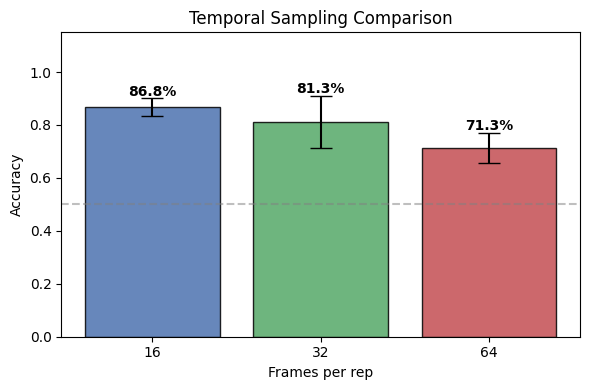


Best temporal sampling: 16 frames (86.8%)


In [10]:
# Temporal comparison
temp_labels = [16, 32, 64]

temp_df = pd.DataFrame({
    "Frames": temp_labels,
    "Mean Accuracy": [f"{np.mean(temporal_results[k]['accs']):.1%}" for k in temp_labels],
    "Std": [f"{np.std(temporal_results[k]['accs']):.1%}" for k in temp_labels],
    "Time (s)": [f"{temporal_results[k]['time']:.0f}" for k in temp_labels],
})
print(temp_df.to_string(index=False))

means_t = [np.mean(temporal_results[k]["accs"]) for k in temp_labels]
stds_t = [np.std(temporal_results[k]["accs"]) for k in temp_labels]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([str(n) for n in temp_labels], means_t, yerr=stds_t, capsize=8,
       color=["#4C72B0", "#55A868", "#C44E52"], alpha=0.85, edgecolor="black")
for i, (m, s) in enumerate(zip(means_t, stds_t)):
    ax.text(i, m + s + 0.01, f"{m:.1%}", ha="center", fontweight="bold")
ax.set_xlabel("Frames per rep")
ax.set_ylabel("Accuracy")
ax.set_title("Temporal Sampling Comparison")
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "temporal_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

WINNER_N_FRAMES = max(temp_labels, key=lambda k: np.mean(temporal_results[k]["accs"]))
print(f"\nBest temporal sampling: {WINNER_N_FRAMES} frames "
      f"({np.mean(temporal_results[WINNER_N_FRAMES]['accs']):.1%})")

---
## Experiment E: Hyperparameter Tuning

Grid search over learning rate and batch size using the best config from above.

In [11]:
def _make_best_model():
    return PushUpSTGCN(in_channels=WINNER_IN_CH, channels=WINNER_CHANNELS)

def _make_best_dataset(reps):
    return PushUpRepSkeletonDataset(reps, n_frames=WINNER_N_FRAMES,
                                    in_channels=WINNER_IN_CH, augment=False)

def _make_best_dataset_aug(reps):
    return PushUpRepSkeletonDataset(reps, n_frames=WINNER_N_FRAMES,
                                    in_channels=WINNER_IN_CH, augment=True)

print(f"Tuning config: {best_capacity} capacity, {WINNER_IN_CH}-channel, {WINNER_N_FRAMES} frames")
print(f"  Trainable params: {_make_best_model().trainable_param_count():,}")

LR_OPTIONS = [5e-4, 1e-3, 5e-3]
BS_OPTIONS = [8, 16, 32]

hp_results = []

for lr in LR_OPTIONS:
    for bs in BS_OPTIONS:
        print(f"\n--- lr={lr}, batch_size={bs} ---")
        t0 = time.time()
        res = run_rep_kfold_cv(
            model_factory=_make_best_model,
            dataset_factory=_make_best_dataset,
            rep_segments=reps_with_kps,
            n_splits=N_SPLITS,
            n_epochs=50,
            batch_size=bs,
            lr=lr,
            patience=15,
            device_str=DEVICE,
            random_state=RANDOM_STATE,
            train_dataset_factory=_make_best_dataset_aug,
        )
        elapsed = time.time() - t0
        accs = [f["val_accuracy"] for f in res["fold_results"]]
        mean_acc = np.mean(accs)
        std_acc = np.std(accs)
        print(f"  Mean: {mean_acc:.1%} +/- {std_acc:.1%} ({elapsed:.0f}s)")

        hp_results.append({
            "lr": lr,
            "batch_size": bs,
            "mean_acc": mean_acc,
            "std_acc": std_acc,
            "per_fold": accs,
            "time": elapsed,
            "results": res,
        })

INFO: Fold 0: train=288 reps (190 vids), val=69 reps (48 vids)


Tuning config: large capacity, 3-channel, 16 frames
  Trainable params: 1,025,602

--- lr=0.0005, batch_size=8 ---
  Fold 0 | Epoch 01/50 | train_loss=0.7262 | val_loss=0.7011 | val_acc=53.6% *
  Fold 0 | Epoch 02/50 | train_loss=0.6398 | val_loss=0.7818 | val_acc=59.4% *
  Fold 0 | Epoch 03/50 | train_loss=0.6491 | val_loss=0.7061 | val_acc=55.1%
  Fold 0 | Epoch 04/50 | train_loss=0.6491 | val_loss=0.7102 | val_acc=65.2% *
  Fold 0 | Epoch 05/50 | train_loss=0.5816 | val_loss=0.7281 | val_acc=62.3%
  Fold 0 | Epoch 06/50 | train_loss=0.6119 | val_loss=1.1546 | val_acc=50.7%
  Fold 0 | Epoch 07/50 | train_loss=0.5282 | val_loss=0.8746 | val_acc=60.9%
  Fold 0 | Epoch 08/50 | train_loss=0.5720 | val_loss=0.7669 | val_acc=56.5%
  Fold 0 | Epoch 09/50 | train_loss=0.5166 | val_loss=0.5549 | val_acc=68.1% *
  Fold 0 | Epoch 10/50 | train_loss=0.4847 | val_loss=0.7396 | val_acc=68.1%
  Fold 0 | Epoch 11/50 | train_loss=0.5443 | val_loss=0.5481 | val_acc=72.5% *
  Fold 0 | Epoch 12/50 | tra

INFO: Fold 0: val_accuracy=0.9130
INFO: Fold 1: train=287 reps (190 vids), val=70 reps (48 vids)


  Fold 0 | Epoch 50/50 | train_loss=0.1790 | val_loss=0.2827 | val_acc=88.4%
  Fold 1 | Epoch 01/50 | train_loss=0.7742 | val_loss=0.7405 | val_acc=51.4% *
  Fold 1 | Epoch 02/50 | train_loss=0.6650 | val_loss=0.6324 | val_acc=57.1% *
  Fold 1 | Epoch 03/50 | train_loss=0.6745 | val_loss=0.6614 | val_acc=60.0% *
  Fold 1 | Epoch 04/50 | train_loss=0.6193 | val_loss=0.6105 | val_acc=61.4% *
  Fold 1 | Epoch 05/50 | train_loss=0.6452 | val_loss=0.6430 | val_acc=61.4%
  Fold 1 | Epoch 06/50 | train_loss=0.5802 | val_loss=0.8824 | val_acc=61.4%
  Fold 1 | Epoch 07/50 | train_loss=0.5487 | val_loss=0.7605 | val_acc=64.3% *
  Fold 1 | Epoch 08/50 | train_loss=0.5268 | val_loss=0.9137 | val_acc=52.9%
  Fold 1 | Epoch 09/50 | train_loss=0.4961 | val_loss=0.5896 | val_acc=71.4% *
  Fold 1 | Epoch 10/50 | train_loss=0.5459 | val_loss=0.6981 | val_acc=65.7%
  Fold 1 | Epoch 11/50 | train_loss=0.4806 | val_loss=0.7510 | val_acc=64.3%
  Fold 1 | Epoch 12/50 | train_loss=0.4317 | val_loss=0.6492 | v

INFO: Fold 1: val_accuracy=0.8714
INFO: Fold 2: train=289 reps (190 vids), val=68 reps (48 vids)


...

  Fold 2 | Epoch 49/50 | train_loss=0.2696 | val_loss=0.9554 | val_acc=69.1%
  Fold 3 | Epoch 01/50 | train_loss=0.8472 | val_loss=0.7439 | val_acc=49.3% *
  Fold 3 | Epoch 02/50 | train_loss=0.7250 | val_loss=0.7131 | val_acc=45.3%
  Fold 3 | Epoch 03/50 | train_loss=0.6982 | val_loss=0.6669 | val_acc=62.7% *
  Fold 3 | Epoch 04/50 | train_loss=0.6804 | val_loss=0.6912 | val_acc=54.7%
  Fold 3 | Epoch 05/50 | train_loss=0.6331 | val_loss=0.6268 | val_acc=66.7% *
  Fold 3 | Epoch 06/50 | train_loss=0.6407 | val_loss=0.6990 | val_acc=62.7%
  Fold 3 | Epoch 07/50 | train_loss=0.6083 | val_loss=0.7186 | val_acc=64.0%
  Fold 3 | Epoch 08/50 | train_loss=0.6235 | val_loss=0.6678 | val_acc=61.3%
  Fold 3 | Epoch 09/50 | train_loss=0.6341 | val_loss=0.6468 | val_acc=58.7%
  Fold 3 | Epoch 10/50 | train_loss=0.6337 | val_loss=0.6338 | val_acc=68.0% *
  Fold 3 | Epoch 11/50 | train_loss=0.6109 | val_loss=0.6183 | val_acc=66.7%
  Fold 3 | Epoch 12/50 | train_loss=0.5829 | val_loss=0.7536 | val_a

INFO: Fold 3: val_accuracy=0.8933
INFO: Fold 4: train=282 reps (191 vids), val=75 reps (47 vids)


  Fold 3 | Epoch 50/50 | train_loss=0.2266 | val_loss=0.5433 | val_acc=86.7%
  Fold 4 | Epoch 01/50 | train_loss=0.9102 | val_loss=0.9039 | val_acc=52.0% *
  Fold 4 | Epoch 02/50 | train_loss=0.7146 | val_loss=1.1930 | val_acc=54.7% *
  Fold 4 | Epoch 03/50 | train_loss=0.6548 | val_loss=0.7269 | val_acc=54.7%
  Fold 4 | Epoch 04/50 | train_loss=0.6719 | val_loss=0.7515 | val_acc=57.3% *
  Fold 4 | Epoch 05/50 | train_loss=0.6645 | val_loss=0.7019 | val_acc=53.3%
  Fold 4 | Epoch 06/50 | train_loss=0.6411 | val_loss=0.6822 | val_acc=61.3% *
  Fold 4 | Epoch 07/50 | train_loss=0.6311 | val_loss=0.6659 | val_acc=69.3% *
  Fold 4 | Epoch 08/50 | train_loss=0.6380 | val_loss=0.7019 | val_acc=65.3%
  Fold 4 | Epoch 09/50 | train_loss=0.6149 | val_loss=1.1008 | val_acc=52.0%
  Fold 4 | Epoch 10/50 | train_loss=0.6246 | val_loss=0.7158 | val_acc=60.0%
  Fold 4 | Epoch 11/50 | train_loss=0.6080 | val_loss=1.0041 | val_acc=57.3%
  Fold 4 | Epoch 12/50 | train_loss=0.5683 | val_loss=0.6927 | val

INFO: Fold 4: val_accuracy=0.8667


  Fold 4 | Epoch 50/50 | train_loss=0.2966 | val_loss=1.1866 | val_acc=80.0%
  Mean: 85.3% +/- 2.4% (66s)


   LR  Batch Size Mean Accuracy  Std Time (s)
5e-04           8         89.6% 3.6%      134
5e-04          16         87.3% 5.7%       75
5e-04          32         87.6% 5.4%       61
1e-03           8         86.2% 4.9%      126
1e-03          16         87.8% 4.3%       86
1e-03          32         86.2% 4.1%       58
5e-03           8         80.8% 4.1%      117
5e-03          16         84.9% 3.3%       79
5e-03          32         85.3% 2.4%       66


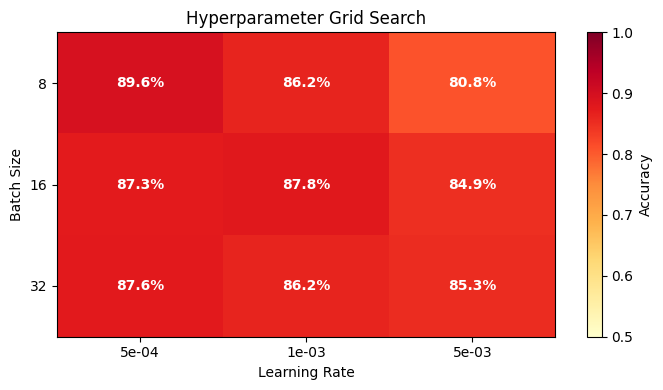


Best hyperparams: lr=5e-04, batch_size=8
  Accuracy: 89.6% +/- 3.6%


In [12]:
# HP results table + heatmap
hp_df = pd.DataFrame([
    {
        "LR": f"{r['lr']:.0e}",
        "Batch Size": r["batch_size"],
        "Mean Accuracy": f"{r['mean_acc']:.1%}",
        "Std": f"{r['std_acc']:.1%}",
        "Time (s)": f"{r['time']:.0f}",
    }
    for r in hp_results
])
print(hp_df.to_string(index=False))

pivot = pd.DataFrame(hp_results).pivot(
    index="batch_size", columns="lr", values="mean_acc"
)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto", vmin=0.5, vmax=1.0)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{c:.0e}" for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Learning Rate")
ax.set_ylabel("Batch Size")
ax.set_title("Hyperparameter Grid Search")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.1%}", ha="center", va="center",
                fontweight="bold", color="white" if val > 0.75 else "black")

plt.colorbar(im, label="Accuracy")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "hp_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

best_hp = max(hp_results, key=lambda r: r["mean_acc"])
print(f"\nBest hyperparams: lr={best_hp['lr']:.0e}, batch_size={best_hp['batch_size']}")
print(f"  Accuracy: {best_hp['mean_acc']:.1%} +/- {best_hp['std_acc']:.1%}")

---
## Final Comparison

Summary of all experiments.

In [13]:
all_experiments = []

# A: Baseline
all_experiments.append({
    "Experiment": "A: Baseline (medium, 2ch, 32f)",
    "Channels": str(CONFIGS["medium"]),
    "Input Ch": 2,
    "Frames": 32,
    "Params": f"{make_baseline_model().trainable_param_count():,}",
    "Mean Acc": np.mean(accs_A),
    "Std": np.std(accs_A),
})

# B: 3-channel (if different from A)
if WINNER_IN_CH == 3:
    all_experiments.append({
        "Experiment": "B: 3-channel (x,y,conf)",
        "Channels": str(CONFIGS["medium"]),
        "Input Ch": 3,
        "Frames": 32,
        "Params": f"{make_3ch_model().trainable_param_count():,}",
        "Mean Acc": np.mean(accs_B),
        "Std": np.std(accs_B),
    })

# C: Capacity variants
for config_name in ["small", "medium", "large"]:
    r = capacity_results[config_name]
    all_experiments.append({
        "Experiment": f"C: {config_name.title()} {CONFIGS[config_name]}",
        "Channels": str(CONFIGS[config_name]),
        "Input Ch": WINNER_IN_CH,
        "Frames": 32,
        "Params": f"{r['params']:,}",
        "Mean Acc": np.mean(r["accs"]),
        "Std": np.std(r["accs"]),
    })

# D: Temporal variants
for nf in [16, 32, 64]:
    r = temporal_results[nf]
    all_experiments.append({
        "Experiment": f"D: {nf} frames",
        "Channels": str(WINNER_CHANNELS),
        "Input Ch": WINNER_IN_CH,
        "Frames": nf,
        "Params": f"{_make_best_model().trainable_param_count():,}",
        "Mean Acc": np.mean(r["accs"]),
        "Std": np.std(r["accs"]),
    })

# E: Best HP
all_experiments.append({
    "Experiment": f"E: Best HP (lr={best_hp['lr']:.0e}, bs={best_hp['batch_size']})",
    "Channels": str(WINNER_CHANNELS),
    "Input Ch": WINNER_IN_CH,
    "Frames": WINNER_N_FRAMES,
    "Params": f"{_make_best_model().trainable_param_count():,}",
    "Mean Acc": best_hp["mean_acc"],
    "Std": best_hp["std_acc"],
})

final_df = pd.DataFrame(all_experiments)
print(final_df.to_string(index=False))

                    Experiment            Channels  Input Ch  Frames    Params  Mean Acc      Std
A: Baseline (medium, 2ch, 32f)       [64, 64, 128]         2      32   244,290  0.766314 0.073650
       B: 3-channel (x,y,conf)       [64, 64, 128]         3      32   244,418  0.824066 0.057878
             C: Small [32, 64]            [32, 64]         3      32    51,362  0.699209 0.058454
       C: Medium [64, 64, 128]       [64, 64, 128]         3      32   244,418  0.783219 0.055123
  C: Large [64, 128, 128, 256] [64, 128, 128, 256]         3      32 1,025,602  0.786081 0.054408
                  D: 16 frames [64, 128, 128, 256]         3      16 1,025,602  0.867633 0.033445
                  D: 32 frames [64, 128, 128, 256]         3      32 1,025,602  0.812928 0.098035
                  D: 64 frames [64, 128, 128, 256]         3      64 1,025,602  0.713006 0.056266
   E: Best HP (lr=5e-04, bs=8) [64, 128, 128, 256]         3      16 1,025,602  0.895757 0.036481


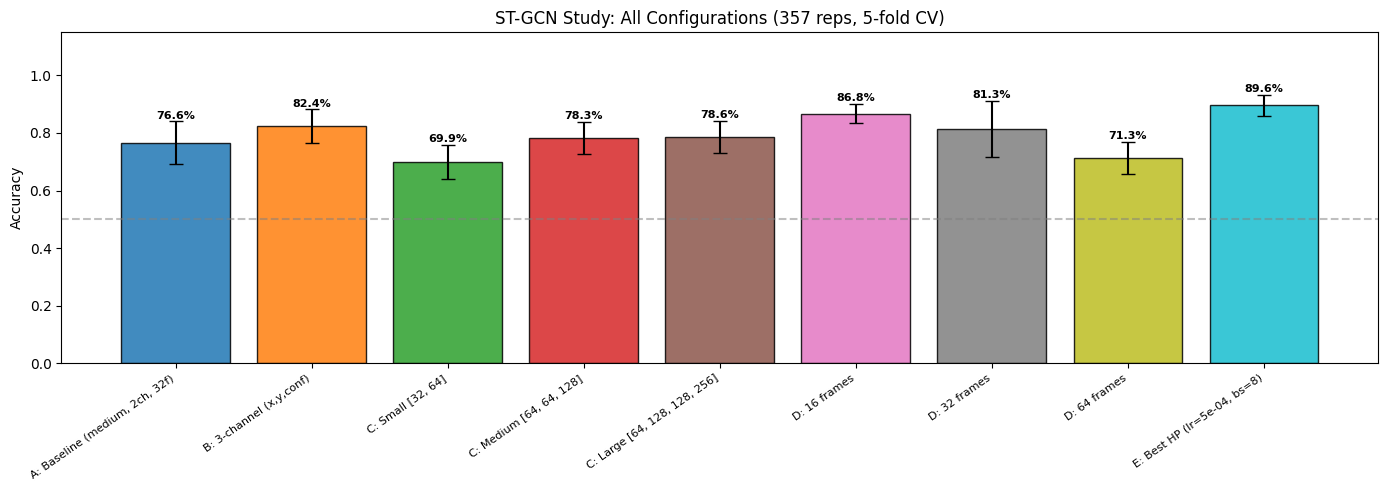


Best overall: E: Best HP (lr=5e-04, bs=8)
  Accuracy: 89.6% +/- 3.6%


In [14]:
# Final bar chart
names = final_df["Experiment"].tolist()
means_f = final_df["Mean Acc"].tolist()
stds_f = final_df["Std"].tolist()

fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(names)))
bars = ax.bar(range(len(names)), means_f, yerr=stds_f, capsize=5,
              color=colors, alpha=0.85, edgecolor="black")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=35, ha="right", fontsize=8)

for bar, m, s in zip(bars, means_f, stds_f):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.01,
            f"{m:.1%}", ha="center", fontweight="bold", fontsize=8)

ax.set_ylabel("Accuracy")
ax.set_title(f"ST-GCN Study: All Configurations ({len(reps_with_kps)} reps, {N_SPLITS}-fold CV)")
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

best_row = final_df.loc[final_df["Mean Acc"].idxmax()]
print(f"\nBest overall: {best_row['Experiment']}")
print(f"  Accuracy: {best_row['Mean Acc']:.1%} +/- {best_row['Std']:.1%}")

---
## Overfitting Analysis

1. Train vs val loss curves
2. Confusion matrices
3. Per-video error analysis

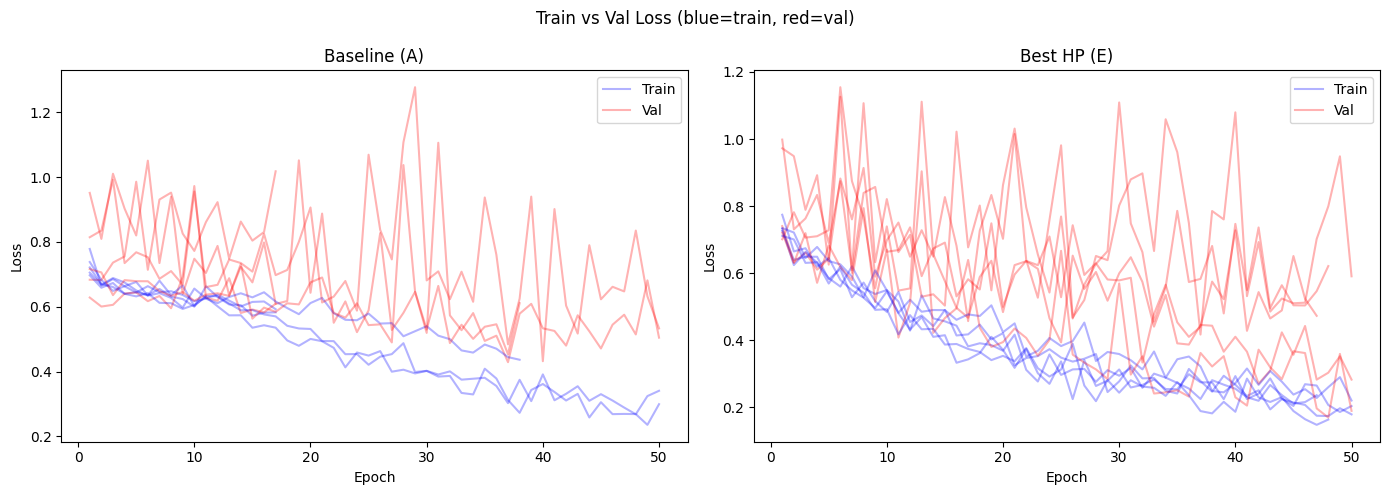

In [15]:
from sklearn.metrics import confusion_matrix, classification_report

# ---- 1. Train vs Val Loss Curves ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

configs_to_plot = [
    ("Baseline (A)", results_A),
    ("Best HP (E)", best_hp["results"]),
]

for ax, (name, res) in zip(axes, configs_to_plot):
    for fold_res in res["fold_results"]:
        if "epoch_train_losses" not in fold_res:
            continue
        epochs = range(1, len(fold_res["epoch_train_losses"]) + 1)
        ax.plot(epochs, fold_res["epoch_train_losses"], "b-", alpha=0.3)
        ax.plot(epochs, fold_res["epoch_val_losses"], "r-", alpha=0.3)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(name)
    ax.legend(["Train", "Val"], loc="upper right")

plt.suptitle("Train vs Val Loss (blue=train, red=val)", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "overfitting_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

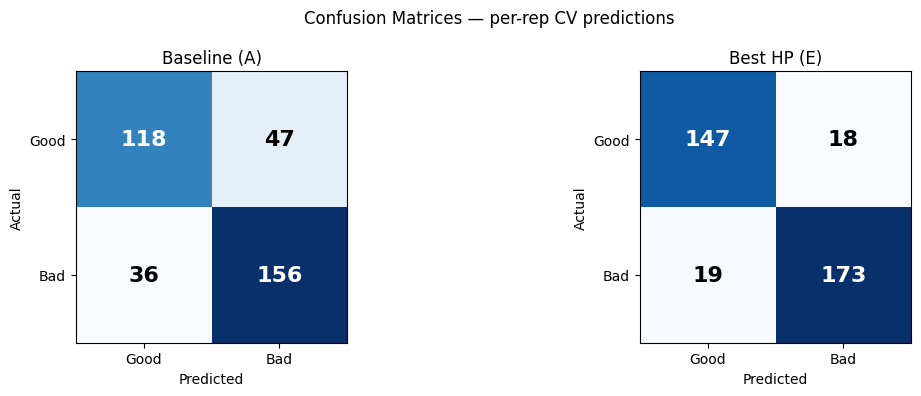


Baseline (A):
              precision    recall  f1-score   support

        Good       0.77      0.72      0.74       165
         Bad       0.77      0.81      0.79       192

    accuracy                           0.77       357
   macro avg       0.77      0.76      0.76       357
weighted avg       0.77      0.77      0.77       357


Best HP (E):
              precision    recall  f1-score   support

        Good       0.89      0.89      0.89       165
         Bad       0.91      0.90      0.90       192

    accuracy                           0.90       357
   macro avg       0.90      0.90      0.90       357
weighted avg       0.90      0.90      0.90       357



In [16]:
# ---- 2. Confusion Matrices ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

configs_cm = [
    ("Baseline (A)", results_A),
    ("Best HP (E)", best_hp["results"]),
]

for ax, (name, res) in zip(axes, configs_cm):
    preds = res["per_rep_preds"]
    true = res["per_rep_true"]
    valid = [(p, t) for p, t in zip(preds, true) if p is not None]
    if not valid:
        continue
    p, t = zip(*valid)
    cm = confusion_matrix(t, p, labels=[0, 1])

    im = ax.imshow(cm, cmap="Blues", interpolation="nearest")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Good", "Bad"])
    ax.set_yticklabels(["Good", "Bad"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(name)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    fontsize=16, fontweight="bold",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.suptitle("Confusion Matrices — per-rep CV predictions", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

for name, res in configs_cm:
    preds = [p for p in res["per_rep_preds"] if p is not None]
    true = [t for p, t in zip(res["per_rep_preds"], res["per_rep_true"]) if p is not None]
    print(f"\n{name}:")
    print(classification_report(true, preds, target_names=["Good", "Bad"]))

In [ ]:
# ---- 3. Per-Video Error Analysis (Best HP model) ----
best_preds = best_hp["results"]["per_rep_preds"]
best_true = best_hp["results"]["per_rep_true"]
best_confs = best_hp["results"].get("per_rep_confs", [None] * len(best_preds))

video_stats = {}
for i, rep in enumerate(reps_with_kps):
    vid = rep["video_id"]
    pred = best_preds[i]
    true = best_true[i]
    conf = best_confs[i] if best_confs[i] is not None else 0.0
    if pred is None:
        continue
    if vid not in video_stats:
        video_stats[vid] = {"correct": 0, "wrong": 0, "label": rep["label"],
                            "wrong_confs": [], "reps": []}
    is_correct = pred == true
    if is_correct:
        video_stats[vid]["correct"] += 1
    else:
        video_stats[vid]["wrong"] += 1
        video_stats[vid]["wrong_confs"].append(conf)
    video_stats[vid]["reps"].append({
        "rep_idx": rep.get("rep_idx", i),
        "pred": pred, "true": true, "conf": conf, "correct": is_correct,
    })

error_videos = {k: v for k, v in video_stats.items() if v["wrong"] > 0}
perfect_videos = {k: v for k, v in video_stats.items() if v["wrong"] == 0}

print(f"Total videos: {len(video_stats)}")
print(f"Perfect (0 errors): {len(perfect_videos)}")
print(f"With errors: {len(error_videos)}")

if error_videos:
    print(f"\n{'Video':<35} {'Label':<8} {'Correct':<10} {'Wrong':<8} {'Avg Conf':<10}")
    print("-" * 75)
    for vid, stats in sorted(error_videos.items(), key=lambda x: -x[1]["wrong"]):
        label = "Good" if stats["label"] == 0 else "Bad"
        avg_conf = np.mean(stats["wrong_confs"]) if stats["wrong_confs"] else 0
        print(f"{vid:<35} {label:<8} {stats['correct']:<10} {stats['wrong']:<8} {avg_conf:<10.1%}")

        # Show individual misclassified reps
        for r in stats["reps"]:
            if not r["correct"]:
                pred_str = "GOOD" if r["pred"] == 0 else "BAD"
                true_str = "GOOD" if r["true"] == 0 else "BAD"
                print(f"  -> Rep {r['rep_idx']}: predicted {pred_str} ({r['conf']:.1%}), actual {true_str}")

good_errors = sum(v["wrong"] for v in error_videos.values() if v["label"] == 0)
bad_errors = sum(v["wrong"] for v in error_videos.values() if v["label"] == 1)
print(f"\nMisclassified reps from 'good' videos: {good_errors}")
print(f"Misclassified reps from 'bad' videos: {bad_errors}")

# ---- Visualizations ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Error distribution histogram
error_counts = [v["wrong"] for v in video_stats.values()]
axes[0].hist(error_counts, bins=range(max(error_counts) + 2), edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Misclassified reps per video")
axes[0].set_ylabel("Number of videos")
axes[0].set_title("Error Distribution")

# (b) Confidence distribution: correct vs wrong
correct_confs = []
wrong_confs = []
for i, rep in enumerate(reps_with_kps):
    pred = best_preds[i]
    true = best_true[i]
    conf = best_confs[i]
    if pred is None or conf is None:
        continue
    if pred == true:
        correct_confs.append(conf)
    else:
        wrong_confs.append(conf)

axes[1].hist(correct_confs, bins=20, alpha=0.6, label=f"Correct ({len(correct_confs)})", color="green", edgecolor="black")
axes[1].hist(wrong_confs, bins=20, alpha=0.6, label=f"Wrong ({len(wrong_confs)})", color="red", edgecolor="black")
axes[1].set_xlabel("Prediction confidence")
axes[1].set_ylabel("Count")
axes[1].set_title("Confidence: Correct vs Wrong")
axes[1].legend()

# (c) Top error videos bar chart
if error_videos:
    top_errors = sorted(error_videos.items(), key=lambda x: -x[1]["wrong"])[:15]
    vids = [v[:20] + "..." if len(v) > 20 else v for v, _ in top_errors]
    wrongs = [s["wrong"] for _, s in top_errors]
    colors = ["#e74c3c" if s["label"] == 1 else "#2ecc71" for _, s in top_errors]
    axes[2].barh(range(len(vids)), wrongs, color=colors, edgecolor="black")
    axes[2].set_yticks(range(len(vids)))
    axes[2].set_yticklabels(vids, fontsize=8)
    axes[2].set_xlabel("Misclassified reps")
    axes[2].set_title("Most Error-Prone Videos")
    axes[2].invert_yaxis()
    from matplotlib.patches import Patch
    axes[2].legend(handles=[Patch(color="#2ecc71", label="Good video"),
                            Patch(color="#e74c3c", label="Bad video")], loc="lower right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Summary ----
print(f"\n{'='*60}")
print(f"  Error Analysis Summary")
print(f"{'='*60}")
total_reps = sum(v["correct"] + v["wrong"] for v in video_stats.values())
total_wrong = sum(v["wrong"] for v in video_stats.values())
print(f"  Total reps evaluated: {total_reps}")
print(f"  Total misclassified: {total_wrong} ({total_wrong/total_reps:.1%})")
print(f"  Videos with errors: {len(error_videos)}/{len(video_stats)} ({len(error_videos)/len(video_stats):.1%})")
if wrong_confs:
    print(f"  Avg confidence on wrong predictions: {np.mean(wrong_confs):.1%}")
    print(f"  Avg confidence on correct predictions: {np.mean(correct_confs):.1%}")

---
## Save Results

In [18]:
# Save summary CSV
final_df.to_csv(OUTPUT_DIR / "stgcn_study_results.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'stgcn_study_results.csv'}")

# Save HP grid CSV
hp_df.to_csv(OUTPUT_DIR / "stgcn_hp_grid.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'stgcn_hp_grid.csv'}")

# Save best model weights + config
if best_hp["results"]["best_state"] is not None:
    torch.save({
        "state_dict": best_hp["results"]["best_state"],
        "in_channels": WINNER_IN_CH,
        "channels": WINNER_CHANNELS,
        "n_frames": WINNER_N_FRAMES,
        "accuracy": best_hp["mean_acc"],
        "lr": best_hp["lr"],
        "batch_size": best_hp["batch_size"],
        "dropout": 0.2,
    }, OUTPUT_DIR / "stgcn_best.pt")
    print(f"Saved: {OUTPUT_DIR / 'stgcn_best.pt'}")

print(f"\nAll outputs saved to: {OUTPUT_DIR.resolve()}")
print("\nFigures:")
for f in sorted(OUTPUT_DIR.glob("*.png")):
    print(f"  {f.name}")
print("CSVs:")
for f in sorted(OUTPUT_DIR.glob("*.csv")):
    print(f"  {f.name}")

Saved: outputs/stgcn_study_results.csv
Saved: outputs/stgcn_hp_grid.csv
Saved: outputs/stgcn_best.pt

All outputs saved to: /workspace/pushup-tracker/stgcn_study/outputs

Figures:
  ab_channels.png
  capacity_comparison.png
  confusion_matrices.png
  error_distribution.png
  final_comparison.png
  hp_heatmap.png
  overfitting_loss_curves.png
  temporal_comparison.png
CSVs:
  stgcn_hp_grid.csv
  stgcn_study_results.csv


---
## Inference Pipelines

Two modes for counting good push-up reps:

1. **Automatic** (`infer_automatic`): State machine auto-detects reps from pre-recorded video, classifies using keypoints only.
2. **Real-time** (`live_demo.py`): Webcam with instant per-rep classification as reps complete. No recording delay.

Key advantage: classification uses skeleton keypoints only — no video frame decoding, no domain gap.

In [3]:
import torch
from pathlib import Path
from inference import load_model, infer_automatic, summarize, print_results

# Auto-detect device
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

model, config = load_model("outputs/stgcn_best.pt", device=device)
print(f"Using device: {device}")
print(f"Input channels: {config.get('in_channels')}")
print(f"Frames per rep: {config.get('n_frames')}")
print(f"CV accuracy: {config.get('accuracy', 0):.1%}")

Using device: mps
Input channels: 3
Frames per rep: 16
CV accuracy: 89.6%


In [ ]:
# Automatic rep detection (no annotation needed)
# Pipeline: YOLO keypoints -> State Machine -> ST-GCN classification
#
# Classification uses keypoints only — no video frame decoding!

KEYPOINT_DIR = Path("keypoints")

auto_test_videos = [
    # "videos/my_test_video.mp4",
]

if not auto_test_videos:
    print("No test videos defined.")
    print("Add video paths to auto_test_videos above, then re-run this cell.")
else:
    all_auto_results = []

    for video_path in auto_test_videos:
        results_auto = infer_automatic(
            video_path=video_path,
            model=model,
            config=config,
            keypoint_dir=KEYPOINT_DIR,
            device=device,
        )
        print_results(results_auto, f"Automatic — {Path(video_path).name}")

        s = summarize(results_auto)
        print(f"\n  GOOD reps: {s['good_reps']} / {s['total_reps']}")

        all_auto_results.extend(results_auto)

In [21]:
# Live webcam demo (real-time per-rep classification)
# Run from terminal:
#   cd stgcn_study
#   python live_demo.py
#   python live_demo.py --camera 1       # external webcam
#   python live_demo.py --no-skeleton    # hide skeleton overlay
#
# Key advantage over R3D:
#   - Classifies from keypoints only (no video crops)
#   - No domain gap between training and live inference
#   - Instant feedback per rep (no recording/processing delay)

print("Live demo must be run from terminal:")
print("  cd stgcn_study")
print("  python live_demo.py")
print()
print("Controls: Q/ESC = quit, R = reset counters")
print("Each rep is classified instantly when completed.")

Live demo must be run from terminal:
  cd stgcn_study
  python live_demo.py

Controls: Q/ESC = quit, R = reset counters
Each rep is classified instantly when completed.


### Inference Pipeline Summary

| | Automatic (`infer_automatic`) | Real-time (`live_demo.py`) |
|---|---|---|
| **Rep detection** | State machine (offline) | State machine (real-time) |
| **Classification input** | Keypoints only | Keypoints only |
| **Pipeline** | YOLO kps -> State Machine -> ST-GCN | Webcam -> YOLO -> State Machine -> ST-GCN |
| **Latency** | Batch (offline) | Instant per-rep |
| **Domain gap** | None | None |

Unlike R3D (which needs video frame crops), ST-GCN classifies from joint coordinates only.
This eliminates the domain gap that caused R3D's live demo to fail.